# Week 11 Lab: Forecasting Bike-Sharing Demand

AIE683 Machine Learning, Hacettepe University.

**Case.** Capital Bikeshare (Washington, D.C.) has to move bikes between stations with trucks and
plan staff shifts. Both decisions are made the day before, so the operator needs an **hourly demand
forecast for tomorrow**. We have two years (2011-2012) of hourly rental counts with calendar and
weather information (OpenML `Bike_Sharing_Demand`, downloaded at runtime).

In this lab we
1. frame forecasting as supervised learning with lag, rolling-window and calendar features,
2. see why shuffled cross-validation is too optimistic and use `TimeSeriesSplit` instead,
3. backtest baselines (naive, seasonal naive, exponential smoothing) against gradient boosting,
   with MAE, RMSE, MAPE and MASE, and log every model to MLflow,
4. compare recursive and direct multi-step forecasts,
5. build prediction intervals with quantile loss,
6. package the final model as a single scikit-learn `Pipeline` (Week 12 registers and serves it).

Sections marked **Try it** match the in-class activities on the slides. Their TODO cells run as
provided; replace the placeholders with your own code. Expected runtime: about 3 minutes.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"  # limit BLAS/OpenMP threads; set before numpy/sklearn load
os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"
%matplotlib inline
import logging
import tempfile
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")  # tqdm notice from mlflow
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from mlflow.models import infer_signature
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_absolute_percentage_error,
                             mean_pinball_loss, root_mean_squared_error)
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer
from statsmodels.tsa.holtwinters import ExponentialSmoothing

try:  # LightGBM needs the OpenMP runtime (on macOS: `brew install libomp`)
    from lightgbm import LGBMRegressor
    HAS_LIGHTGBM = True
except (ImportError, OSError) as err:
    HAS_LIGHTGBM = False
    print("LightGBM not available, skipping it:", str(err).splitlines()[0][:100])

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("mlflow").setLevel(logging.ERROR)
SEED = 0

## 1. The data

17,379 hourly rows. The dataset has no timestamp column; rows are in time order and a few hours
(mostly at night, when nobody rented a bike) are missing. We treat consecutive rows as consecutive
hours, which is a small approximation. In your own projects, reindex to a complete hourly grid first.

In [2]:
bikes = fetch_openml("Bike_Sharing_Demand", version=2, as_frame=True).frame
y = bikes["count"].astype(float)
X = bikes.drop(columns="count")
print(X.shape)
X.head()

(17379, 12)


,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0


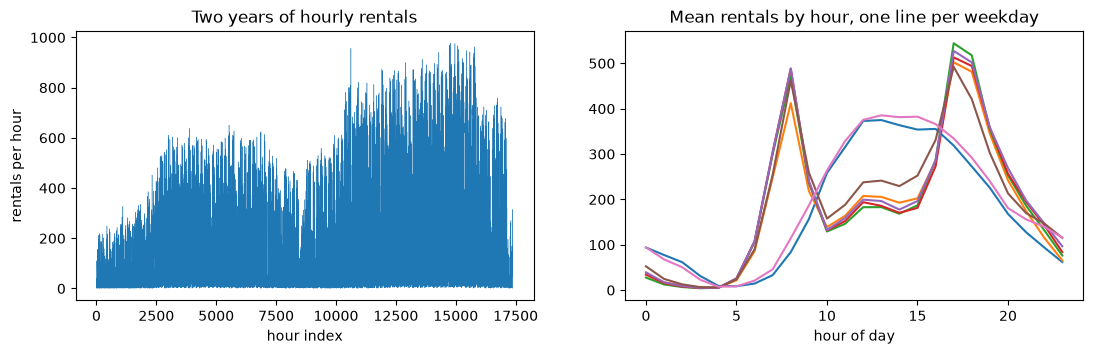

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(y.to_numpy(), lw=0.3)
axes[0].set(title="Two years of hourly rentals", xlabel="hour index", ylabel="rentals per hour")
profile = bikes.groupby(["weekday", "hour"], observed=True)["count"].mean().unstack(0)
profile.plot(ax=axes[1], legend=False)
axes[1].set(title="Mean rentals by hour, one line per weekday", xlabel="hour of day")
plt.show()

## 2. Forecasting as supervised learning

A row of the training table is "features known at the time the forecast is made" and the target is
the count at the target hour. The forecast is made **24 hours ahead**, so any feature derived from
the target must be at least 24 hours old: `shift(k)` with `k >= 24`, and rolling windows computed on
the *shifted* series. Calendar and weather columns describe the target hour itself. (Using observed
weather is optimistic: in production we would only have a weather *forecast*.)

In [4]:
HORIZON = 24


def add_lag_features(frame, target, horizon=HORIZON):
    """Add lag and rolling-window features that are available `horizon` hours in advance."""
    shifted = target.shift(horizon)
    return frame.assign(
        lag_24=shifted,
        lag_48=target.shift(horizon + 24),
        lag_168=target.shift(168),
        roll_mean_24=shifted.rolling(24).mean(),
        roll_max_24=shifted.rolling(24).max(),
    )


XL = add_lag_features(X, y)
XL[["hour", "temp", "lag_24", "lag_48", "lag_168", "roll_mean_24"]].iloc[166:171]

,hour,temp,lag_24,lag_48,lag_168,roll_mean_24
166,5,6.56,5.0,1.0,NaN,67.458333
167,6,6.56,34.0,4.0,NaN,68.708333
168,7,6.56,84.0,36.0,16.0,70.708333
169,8,6.56,210.0,95.0,40.0,75.500000
170,9,6.56,134.0,219.0,32.0,71.958333


## 3. Random K-fold versus `TimeSeriesSplit`

In Weeks 2-3 we saw that cross-validation is only honest when the splits mimic how the model is used.
Shuffled K-fold puts hours from *next week* in the training set and neighbouring hours in the test
set. `TimeSeriesSplit` always trains on the past and tests on the future; `gap` drops a few rows
between them so that windows overlapping the boundary cannot leak.

In [5]:
hgb = HistGradientBoostingRegressor(categorical_features="from_dtype", random_state=SEED)
cv_time = TimeSeriesSplit(n_splits=5, test_size=1000, gap=48)
for name, cv in [("shuffled KFold", KFold(5, shuffle=True, random_state=SEED)),
                 ("TimeSeriesSplit", cv_time)]:
    mae = -cross_val_score(hgb, XL, y, cv=cv, scoring="neg_mean_absolute_error")
    print(f"{name:16s} MAE {mae.mean():6.1f} +- {mae.std():.1f}")

shuffled KFold   MAE   29.7 +- 0.5


TimeSeriesSplit  MAE   46.0 +- 6.7


## Try it 1: find the leak (10 minutes)

A colleague sends you the feature table below for the **day-ahead** forecast and reports an
excellent cross-validated MAE, even with `TimeSeriesSplit`.
1. Before running anything: which of the three features could not exist at 18:00 the day before?
2. Run the cell and compare with the honest features from Section 2.
3. Fix the table in the TODO cell so that every feature is available 24 hours in advance, and rerun.

In [6]:
colleague = X.assign(
    lag_1=y.shift(1),
    lag_24=y.shift(24),
    smooth_24=y.rolling(24, center=True).mean(),
)
mae = -cross_val_score(hgb, colleague, y, cv=cv_time, scoring="neg_mean_absolute_error")
print(f"colleague's features: MAE {mae.mean():.1f}")

colleague's features: MAE 29.2


In [7]:
# TODO: build `fixed` so that every target-derived feature is at least 24 hours old.
fixed = colleague.copy()  # placeholder: replace with your leak-free version
mae = -cross_val_score(hgb, fixed, y, cv=cv_time, scoring="neg_mean_absolute_error")
print(f"fixed features: MAE {mae.mean():.1f}")

fixed features: MAE 29.2


## 4. Calendar features

`hour`, `weekday` and `month` are cyclic: hour 23 is next to hour 0. For linear models an integer
encoding is useless, one-hot encoding works but ignores that neighbouring hours are similar, and
**periodic splines** give smooth, wrap-around bases (see scikit-learn's "Time-related feature
engineering" example). Trees can split integers directly, so for gradient boosting the choice
matters much less.

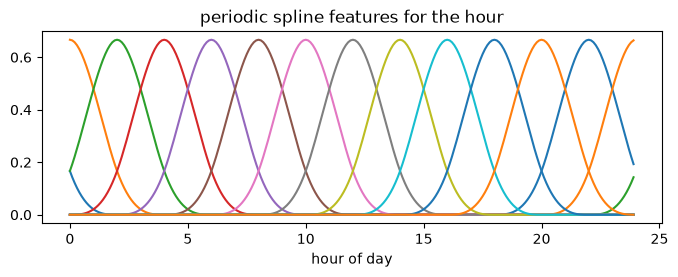

In [8]:
def periodic_spline(period, n_splines):
    """Smooth periodic basis for a cyclic feature with values in [0, period)."""
    knots = np.linspace(0, period, n_splines + 1).reshape(-1, 1)
    return SplineTransformer(degree=3, knots=knots, extrapolation="periodic")


hours = np.arange(0, 24, 0.1).reshape(-1, 1)
plt.figure(figsize=(8, 2.5))
plt.plot(hours, periodic_spline(24, 12).fit_transform(hours))
plt.xlabel("hour of day")
plt.title("periodic spline features for the hour")
plt.show()

## 5. A day-ahead backtest

We use three folds, each testing on four weeks (672 hours) at the end of 2012 and training on
everything before. For the classical baselines we make one 24-hour forecast per test day, using only
data before that day:

* **naive**: repeat the last observed hour,
* **seasonal naive**: the same hour yesterday (lag 24) or last week (lag 168),
* **ETS**: Holt-Winters exponential smoothing with a daily season, refit every day on 4 weeks.

Metrics: MAE, RMSE, MAPE and **MASE** = MAE / (in-sample MAE of the seasonal-naive-24 forecast
on the training fold). MASE < 1 means "better than yesterday's value at the same hour".

In [9]:
cv_bt = TimeSeriesSplit(n_splits=3, test_size=24 * 28)


def metrics(y_true, y_pred, y_train):
    scale = np.mean(np.abs(y_train[24:] - y_train[:-24]))
    mae = mean_absolute_error(y_true, y_pred)
    return {"mae": mae, "rmse": root_mean_squared_error(y_true, y_pred),
            "mape": mean_absolute_percentage_error(y_true, y_pred), "mase": mae / scale}


def baseline_forecasts(test_idx):
    """Classical baselines, one 24-hour forecast per test day."""
    y_np = y.to_numpy()
    naive, ets = [], []
    for start in range(test_idx[0], test_idx[-1] + 1, 24):
        naive.append(np.repeat(y_np[start - 1], 24))
        hist = y_np[start - 24 * 28:start]
        ets.append(ExponentialSmoothing(hist, seasonal="add", seasonal_periods=24).fit().forecast(24))
    n = len(test_idx)
    return {"naive": np.concatenate(naive)[:n],
            "seasonal_naive_24": y_np[test_idx - 24],
            "seasonal_naive_168": y_np[test_idx - 168],
            "ets_holt_winters": np.concatenate(ets)[:n]}


def backtest(model=None, features=None, baseline=None):
    """Return a DataFrame of per-fold metrics for an ML model or a named baseline."""
    rows = []
    for fold, (tr, te) in enumerate(cv_bt.split(X)):
        y_tr, y_te = y.iloc[tr].to_numpy(), y.iloc[te].to_numpy()
        if baseline is not None:
            pred = baseline_forecasts(te)[baseline]
        else:
            pred = model.fit(features.iloc[tr], y.iloc[tr]).predict(features.iloc[te])
        rows.append({"fold": fold, **metrics(y_te, pred, y_tr)})
    return pd.DataFrame(rows)

**Before you run the next cells:** write down which model you expect to win and by how much.
That is the first half of *Try it 2*.

In [10]:
candidates = {
    "hgb_calendar_weather": (HistGradientBoostingRegressor(categorical_features="from_dtype",
                                                           random_state=SEED), X),
    "hgb_with_lags": (HistGradientBoostingRegressor(categorical_features="from_dtype",
                                                    random_state=SEED), XL),
}
if HAS_LIGHTGBM:
    candidates["lightgbm_with_lags"] = (LGBMRegressor(n_estimators=300, learning_rate=0.05,
                                                      random_state=SEED, verbose=-1), XL)

results = {}
for name in ["naive", "seasonal_naive_24", "seasonal_naive_168", "ets_holt_winters"]:
    results[name] = backtest(baseline=name)
for name, (model, features) in candidates.items():
    results[name] = backtest(model, features)

summary = pd.DataFrame({name: df.drop(columns="fold").mean() for name, df in results.items()}).T
summary.sort_values("mae").round(3)

,mae,rmse,mape,mase
hgb_calendar_weather,44.267,68.139,0.723,0.684
lightgbm_with_lags,48.513,76.993,1.032,0.752
hgb_with_lags,51.474,80.648,1.205,0.798
seasonal_naive_24,76.611,124.441,0.911,1.188
seasonal_naive_168,95.336,156.637,2.024,1.478
ets_holt_winters,150.685,193.042,5.142,2.340
naive,165.289,208.953,6.158,2.566


Note the MAPE column: at night there are hours with 1-5 rentals, so a miss of 10 bikes is a
200-1000% error. MAPE is dominated by the hours that matter least to the operator.

## 6. Logging the backtest to MLflow

One run per model, with its parameters, the mean metrics and the per-fold MAE. The tracking store
goes to a temporary directory; set `PERSIST = True` to write `mlflow.db` / `mlruns/` next to the
notebook (git-ignored) and browse with
`uv run mlflow ui --backend-store-uri sqlite:///mlflow.db`.

In [11]:
PERSIST = False
tracking_dir = Path(".").resolve() if PERSIST else Path(tempfile.mkdtemp(prefix="week11-mlflow-"))
mlflow.set_tracking_uri(f"sqlite:///{tracking_dir / 'mlflow.db'}")
EXPERIMENT = "week11-time-series"
if mlflow.get_experiment_by_name(EXPERIMENT) is None:
    mlflow.create_experiment(EXPERIMENT, artifact_location=(tracking_dir / "mlruns").as_uri())
mlflow.set_experiment(EXPERIMENT)


def log_backtest(name, fold_metrics, model=None, features=None):
    with mlflow.start_run(run_name=name):
        mlflow.set_tags({"task": "day-ahead forecast", "cv": "TimeSeriesSplit(3 x 672h)"})
        if model is not None:
            mlflow.log_params({k: v for k, v in model.get_params().items()
                               if isinstance(v, (int, float, str, bool)) or v is None})
            mlflow.log_param("features", ",".join(features.columns))
        mlflow.log_metrics({f"backtest_{k}": v for k, v in fold_metrics.drop(columns="fold").mean().items()})
        for _, row in fold_metrics.iterrows():
            mlflow.log_metric("fold_mae", row["mae"], step=int(row["fold"]))


for name, fold_metrics in results.items():
    model, features = candidates.get(name, (None, None))
    log_backtest(name, fold_metrics, model, features)

runs = mlflow.search_runs(experiment_names=[EXPERIMENT], order_by=["metrics.backtest_mae ASC"])
runs[["tags.mlflow.runName", "metrics.backtest_mae", "metrics.backtest_mase"]]

,tags.mlflow.runName,metrics.backtest_mae,metrics.backtest_mase
0,hgb_calendar_weather,44.267447,0.684237
1,lightgbm_with_lags,48.513170,0.752164
2,hgb_with_lags,51.474380,0.798065
3,seasonal_naive_24,76.610615,1.188253
4,seasonal_naive_168,95.335813,1.478417
5,ets_holt_winters,150.684551,2.339546
6,naive,165.289187,2.566263


## Try it 2: predict the winner, then beat it (15 minutes)

1. Was your prediction from Section 5 right? Why might the lag features *not* help here, and why
   is the fold-to-fold spread so different between models? (Look at `results[...]`.)
2. Beat the best backtest MAE with a model of your own. Ideas: `loss="poisson"` (counts!),
   different lags, `max_iter` / `learning_rate`, a log-transformed target with
   `TransformedTargetRegressor`. Keep the backtest protocol unchanged, it is the referee.
3. Log your model with `log_backtest` so it appears next to the others.

In [12]:
# TODO: define `my_model` and `my_features`, then run the backtest.
my_model = HistGradientBoostingRegressor(categorical_features="from_dtype", random_state=SEED)
my_features = X
mine = backtest(my_model, my_features)
print(mine.round(3))
print("my backtest MAE:", round(mine["mae"].mean(), 1), " best so far:", round(summary["mae"].min(), 1))
log_backtest("my_model", mine, my_model, my_features)

   fold     mae    rmse   mape   mase
0     0  41.273  61.455  0.439  0.650
1     1  45.157  74.553  0.541  0.695
2     2  46.372  68.408  1.188  0.708
my backtest MAE: 44.3  best so far: 44.3


## 7. Multi-step strategies: recursive versus direct

To forecast hours 1..24 after the origin we can
* **recursive**: train one 1-step model (lags 1, 2, 3, 24, 168) and feed its own predictions back as
  lag inputs for the next step, or
* **direct**: train a separate model for each horizon h, using only lags >= h.

We train on everything before the last 4 weeks and evaluate from 14 origins, every other day at
roughly midnight. Because of that, horizon h is also (roughly) hour h of the day: the error curve
mixes the horizon effect with the daily demand pattern.

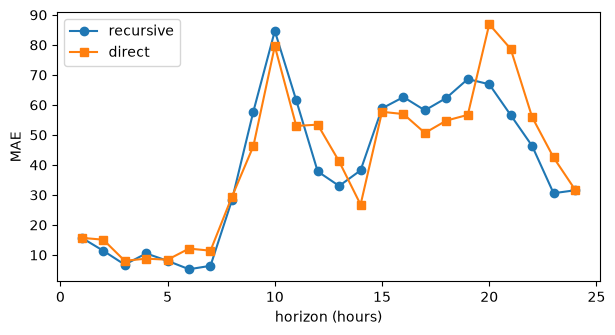

mean MAE over 24 horizons: recursive 39.5, direct 40.9


In [13]:
test_start = len(y) - 24 * 28
origins = list(range(test_start, len(y) - 23, 48))
H = 24


def with_lags(lags):
    return X.assign(**{f"lag_{k}": y.shift(k) for k in lags})


rec_lags = [1, 2, 3, 24, 168]
rec_model = HistGradientBoostingRegressor(categorical_features="from_dtype", random_state=SEED)
F1 = with_lags(rec_lags)
rec_model.fit(F1.iloc[168:test_start], y.iloc[168:test_start])
rec_err = np.zeros(H)
for o in origins:
    y_work = y.to_numpy().copy()
    y_work[o:] = np.nan  # the future is unknown
    for h in range(H):
        row = X.iloc[[o + h]].assign(**{f"lag_{k}": y_work[o + h - k] for k in rec_lags})
        y_work[o + h] = rec_model.predict(row)[0]
    rec_err += np.abs(y_work[o:o + H] - y.to_numpy()[o:o + H]) / len(origins)

dir_err = np.zeros(H)
for h in range(1, H + 1):
    Fh = with_lags(sorted({h, h + 1, h + 2, 24, 168}))
    m = HistGradientBoostingRegressor(categorical_features="from_dtype", random_state=SEED)
    m.fit(Fh.iloc[168:test_start], y.iloc[168:test_start])
    idx = [o + h - 1 for o in origins]
    dir_err[h - 1] = mean_absolute_error(y.iloc[idx], m.predict(Fh.iloc[idx]))

plt.figure(figsize=(7, 3.5))
plt.plot(range(1, H + 1), rec_err, "o-", label="recursive")
plt.plot(range(1, H + 1), dir_err, "s-", label="direct")
plt.xlabel("horizon (hours)")
plt.ylabel("MAE")
plt.legend()
plt.show()
print(f"mean MAE over 24 horizons: recursive {rec_err.mean():.1f}, direct {dir_err.mean():.1f}")

## 8. Prediction intervals with quantile loss

Training gradient boosting with the pinball (quantile) loss for q = 0.05 and q = 0.95 gives a
90% prediction interval. We check it on the last four weeks: the empirical coverage should be close
to 0.90.

coverage 0.78, mean width 178 bikes
pinball loss q=0.05: 7.1
pinball loss q=0.95: 5.7


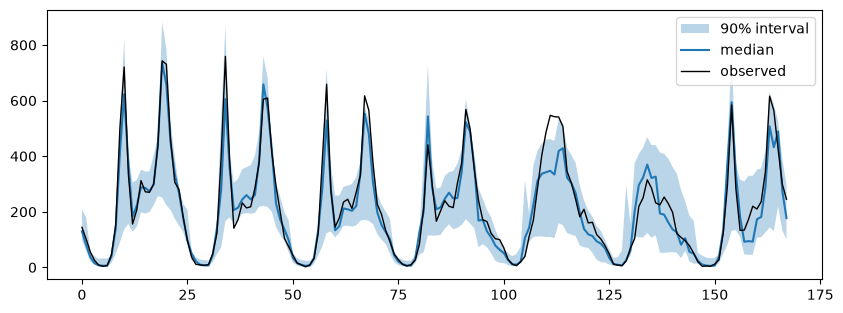

In [14]:
tr, te = slice(0, test_start), slice(test_start, len(y))
quantiles = {}
for q in (0.05, 0.5, 0.95):
    m = HistGradientBoostingRegressor(loss="quantile", quantile=q, categorical_features="from_dtype",
                                      random_state=SEED)
    quantiles[q] = m.fit(X.iloc[tr], y.iloc[tr]).predict(X.iloc[te])
y_te = y.iloc[te].to_numpy()
inside = (y_te >= quantiles[0.05]) & (y_te <= quantiles[0.95])
print(f"coverage {inside.mean():.2f}, mean width {np.mean(quantiles[0.95] - quantiles[0.05]):.0f} bikes")
for q in (0.05, 0.95):
    print(f"pinball loss q={q}: {mean_pinball_loss(y_te, quantiles[q], alpha=q):.1f}")

n = 24 * 7
plt.figure(figsize=(10, 3.5))
plt.fill_between(np.arange(n), quantiles[0.05][:n], quantiles[0.95][:n], alpha=0.3, label="90% interval")
plt.plot(quantiles[0.5][:n], label="median")
plt.plot(y_te[:n], "k", lw=1, label="observed")
plt.legend()
plt.show()

## Try it 3: is the interval right at every hour? (10 minutes)

Overall coverage can be fine while the interval is too narrow at rush hour and too wide at night.
Compute the coverage **per hour of day** (the test rows' `X["hour"]`), plot it, and discuss: which
hours are under-covered, and what would you change? (Ideas: a log target, conformal calibration per
hour, quantile models with lag features.)

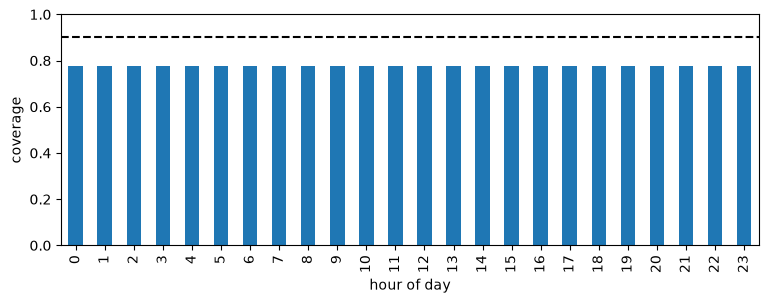

In [15]:
hour_te = X["hour"].iloc[te].to_numpy()
# TODO: compute `coverage_by_hour`, a Series indexed by hour (0-23) with the fraction of test
# rows whose observed count lies inside the 90% interval.
coverage_by_hour = pd.Series(inside.mean(), index=range(24))  # placeholder: overall value
ax = coverage_by_hour.plot(kind="bar", figsize=(9, 3))
ax.axhline(0.9, color="k", ls="--")
ax.set(xlabel="hour of day", ylabel="coverage", ylim=(0, 1))
plt.show()

## 9. The final model as one `Pipeline` (used again in Week 12)

> **Spoiler for Try it 2.** This section shows one strong answer. Finish Try it 2 (and post your score) before you read or run it.


The best model in our backtest needs only calendar and weather columns, so the whole model is a
single scikit-learn `Pipeline` that takes the raw 12 input columns: no lag bookkeeping at serving
time. Categorical columns are one-hot encoded (with `handle_unknown="ignore"` so an unseen category
at serving time does not crash), cyclic columns get periodic splines, and the rest passes through.
We fit it on all data and log it to MLflow with a signature and an input example.

In [16]:
CATEGORICAL = ["season", "holiday", "workingday", "weather"]


def make_forecaster():
    features = ColumnTransformer(
        [("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
         ("hour", periodic_spline(24, 12), ["hour"]),
         ("weekday", periodic_spline(7, 3), ["weekday"]),
         ("month", periodic_spline(12, 6), ["month"])],
        remainder="passthrough",
        verbose_feature_names_out=False,
    )
    return Pipeline([("features", features),
                     ("model", HistGradientBoostingRegressor(loss="poisson", max_iter=300,
                                                             learning_rate=0.05, random_state=SEED))])


X_serve = X.astype({c: str for c in CATEGORICAL})  # plain strings: easy to send as JSON
final_bt = backtest(make_forecaster(), X_serve)
print("final pipeline backtest MAE:", round(final_bt["mae"].mean(), 1))

forecaster = make_forecaster().fit(X_serve, y)
signature = infer_signature(X_serve.head(), forecaster.predict(X_serve.head()))
# MLflow stores scikit-learn models with skops, which only loads types we explicitly trust.
TRUSTED_TYPES = ["sklearn.ensemble._hist_gradient_boosting.predictor.TreePredictor",
                 "scipy.interpolate._bsplines.BSpline", "scipy.interpolate._bsplines._BSpline"]
with mlflow.start_run(run_name="final_pipeline") as run:
    mlflow.log_metrics({f"backtest_{k}": v for k, v in final_bt.drop(columns="fold").mean().items()})
    mlflow.sklearn.log_model(forecaster, name="model", signature=signature,
                             input_example=X_serve.head(3),
                             skops_trusted_types=TRUSTED_TYPES)

loaded = mlflow.pyfunc.load_model(f"runs:/{run.info.run_id}/model")
print(loaded.predict(X_serve.tail(3)), y.tail(3).to_numpy())

final pipeline backtest MAE: 40.5


[83.83186207 63.91719311 35.64706974] [90. 61. 49.]
